In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("train.csv")

In [26]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order_Month,Order_Year,Ship_Month,Ship_Year
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,11,2017,11,2017
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,11,2017,11,2017
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,6,2017,6,2017
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10,2016,10,2016
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,10,2016,10,2016


In [23]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [13]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [12]:
df["Postal Code"]=(df['Postal Code'].mean())

In [21]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)


In [22]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [25]:

df['Order_Month'] = df['Order Date'].dt.month
df['Order_Year']  = df['Order Date'].dt.year

df['Ship_Month'] = df['Ship Date'].dt.month
df['Ship_Year']  = df['Ship Date'].dt.year


In [28]:
df.to_csv('salespulse_clean.csv', index=False)
print("Saved!")

Saved!


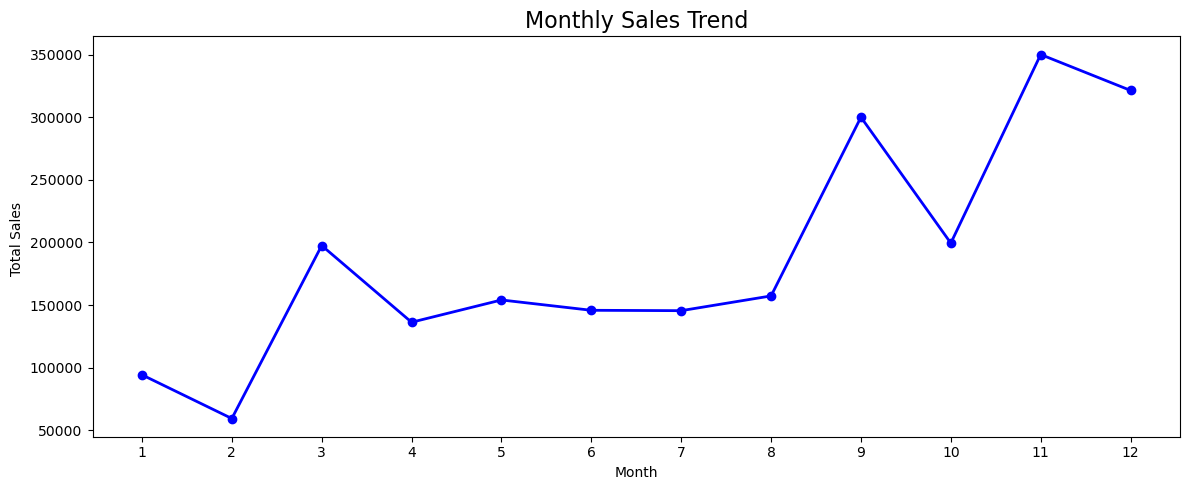

In [117]:
monthly_sales = df.groupby('Order_Month')['Sales'].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='blue', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Sales ')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig("monthly sales trend.png", dpi=200)
plt.show()

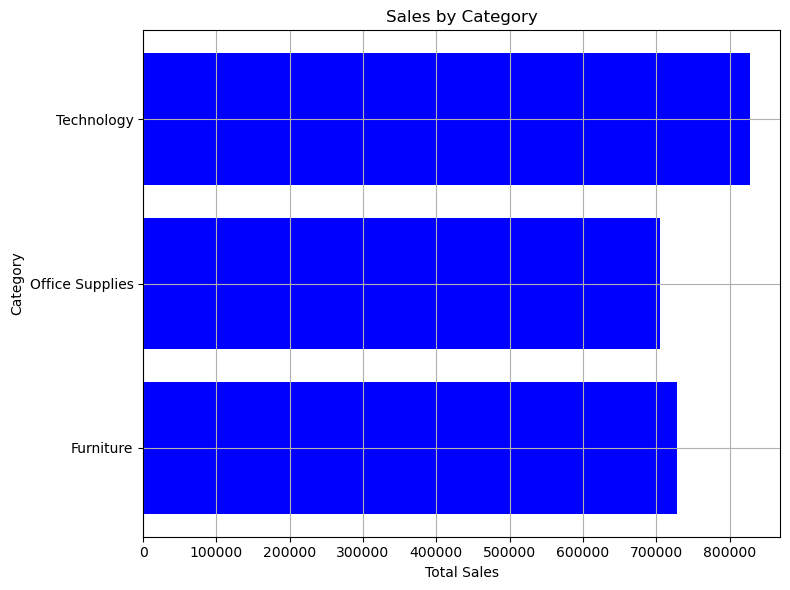

In [52]:

sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,6))
plt.barh(sales.index, sales.values, color='blue')
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.title("Sales by Category")
plt.grid()   
plt.tight_layout()
plt.savefig('sales_by_Category.png', dpi=150)


plt.show()



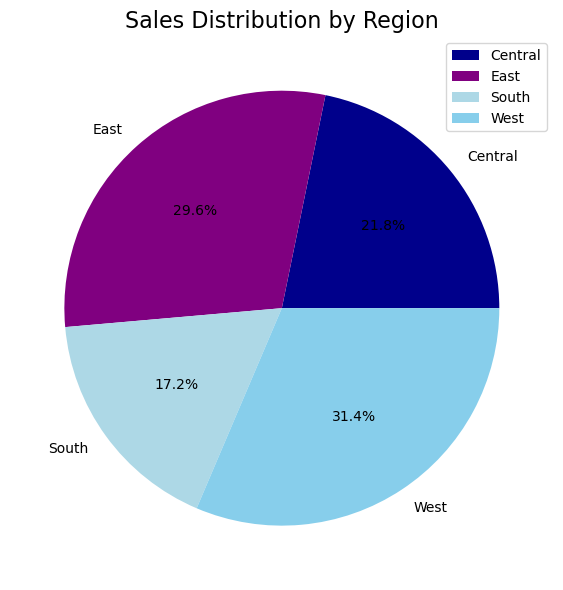

In [48]:

region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8, 6))
plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct='%1.1f%%',
    colors=['darkblue', 'purple', 'lightblue', 'skyblue'] 
)
plt.title('Sales Distribution by Region', fontsize=16)
plt.tight_layout()
plt.legend()
plt.savefig('sales_by_region.png', dpi=150)
plt.show()


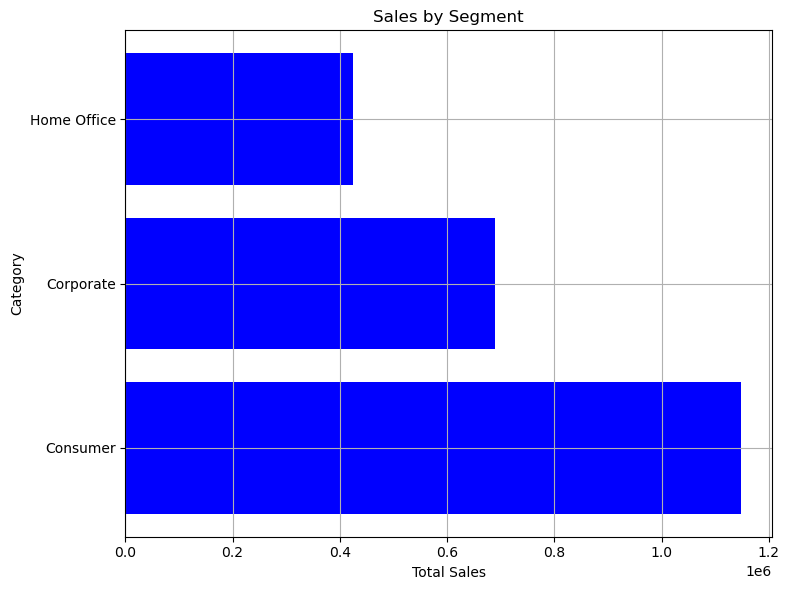

In [61]:

sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(8,6))
plt.barh(sales.index, sales.values, color='blue')
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.title("Sales by Segment")
plt.grid()   
plt.tight_layout()
plt.savefig('sales_by_Segment.png', dpi=150)


plt.show()



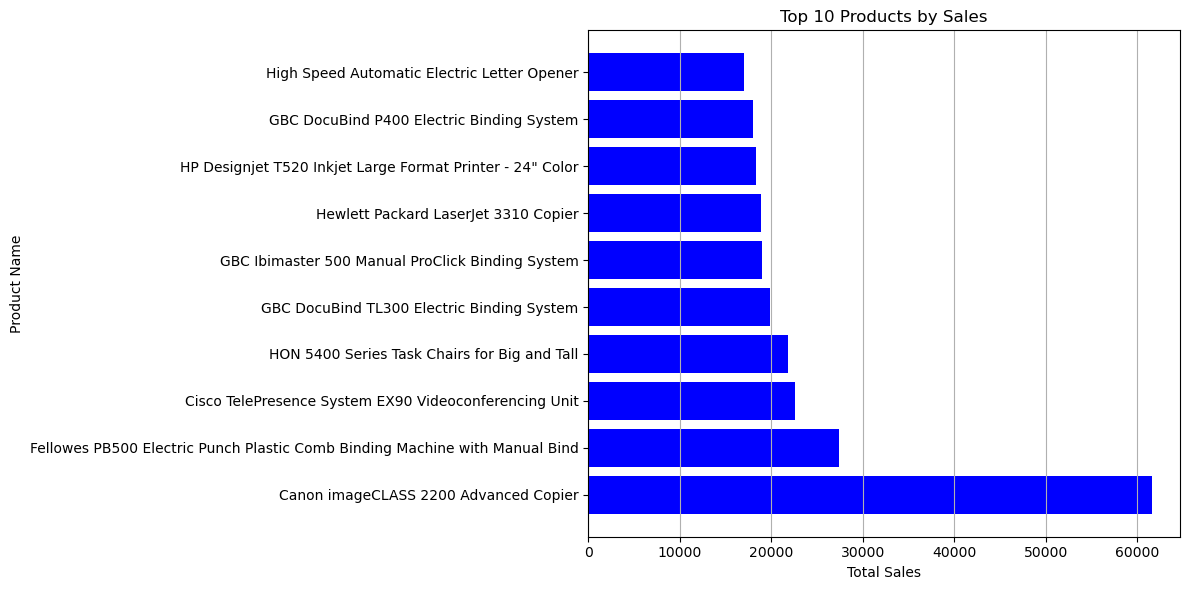

In [63]:
sales = df.groupby('Product Name')['Sales'].sum().nlargest(10)

plt.figure(figsize=(12,6))
plt.barh(sales.index, sales.values, color='blue')
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.title("Top 10 Products by Sales")
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('top_10_products.png', dpi=150)
plt.show()


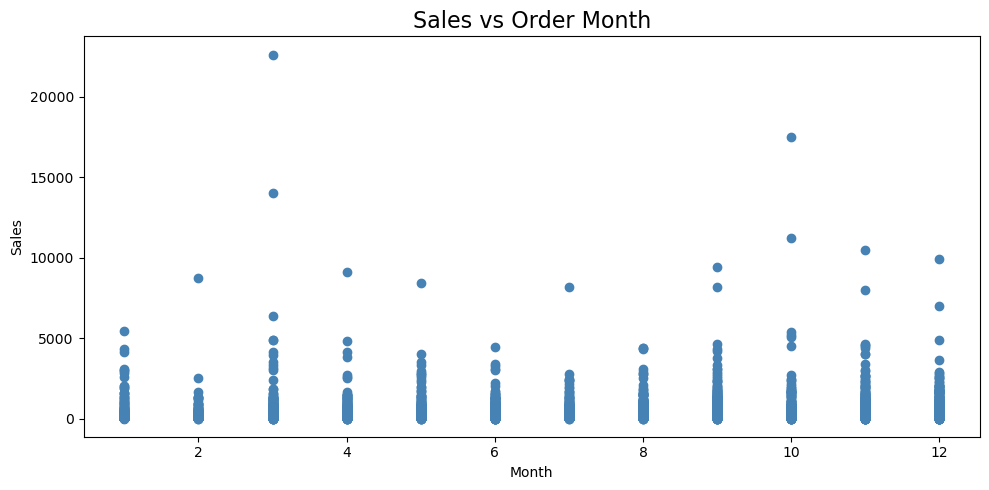

In [68]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Order_Month'], df['Sales'], color='steelblue')
plt.title('Sales vs Order Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('sales vs oder month.png', dpi=150)


plt.show()

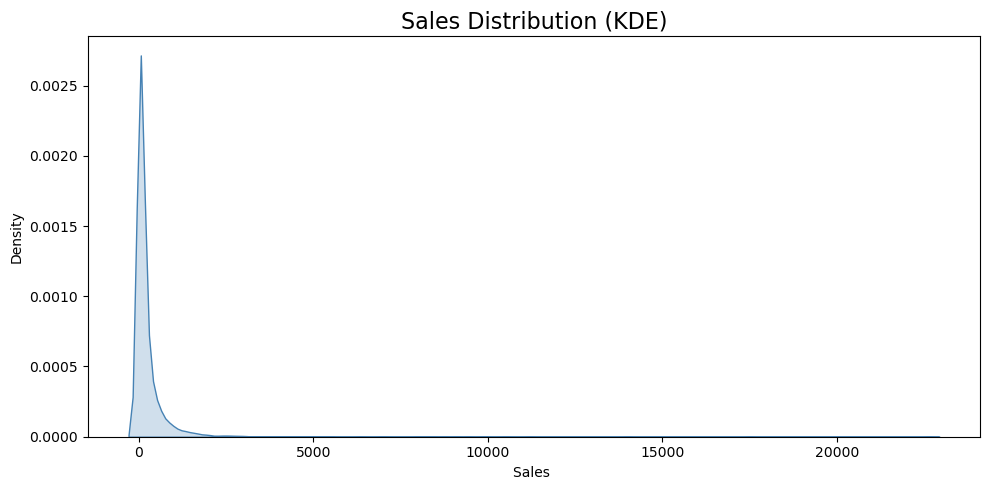

In [70]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df['Sales'], fill=True, color='steelblue')
plt.title('Sales Distribution (KDE)', fontsize=16)
plt.xlabel('Sales ')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

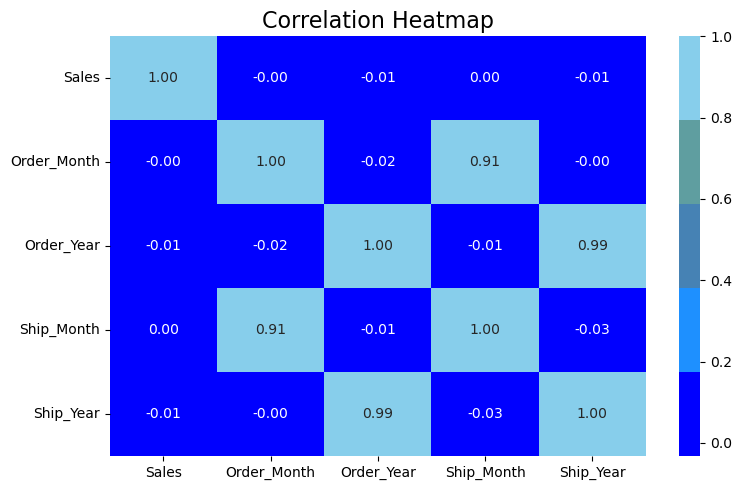

In [77]:

corr = df[['Sales', 'Order_Month', 'Order_Year', 'Ship_Month', 'Ship_Year']].corr()

blue_shades = [
    "#0000FF",   # Pure Blue
    "#1E90FF",   # Dodger Blue
    "#4682B4",   # Steel Blue
    "#5F9EA0",   # Cadet Blue
    "#87CEEB"    # Sky Blue
]

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr, cmap=sns.color_palette(blue_shades), annot=True, fmt=".2f")
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=250)
plt.show()


In [99]:
df_ml=df.copy()

In [100]:
drop_cols = ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 
             'Customer ID', 'Customer Name', 'Country', 
             'City', 'State', 'Postal Code', 'Product ID', 'Product Name']

df_ml = df_ml.drop(columns=drop_cols)

df_ml = pd.get_dummies(df_ml, columns=['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category'])

In [104]:
df_ml.head()

,Sales,Order_Month,Order_Year,Ship_Month,Ship_Year,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Consumer,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,261.9600,11,2017,11,2017,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1,731.9400,11,2017,11,2017,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,14.6200,6,2017,6,2017,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
3,957.5775,10,2016,10,2016,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,1
4,22.3680,10,2016,10,2016,0,0,0,1,1,...,0,0,0,0,0,0,0,1,0,0


In [102]:
df_ml=df_ml.replace(False, '0')

In [103]:
df_ml=df_ml.replace(True, '1')

In [105]:
print(df_ml.shape)
print(df_ml.dtypes)

(9800, 36)
Sales                       float64
Order_Month                   int32
Order_Year                    int32
Ship_Month                    int32
Ship_Year                     int32
Ship Mode_First Class        object
Ship Mode_Same Day           object
Ship Mode_Second Class       object
Ship Mode_Standard Class     object
Segment_Consumer             object
Segment_Corporate            object
Segment_Home Office          object
Region_Central               object
Region_East                  object
Region_South                 object
Region_West                  object
Category_Furniture           object
Category_Office Supplies     object
Category_Technology          object
Sub-Category_Accessories     object
Sub-Category_Appliances      object
Sub-Category_Art             object
Sub-Category_Binders         object
Sub-Category_Bookcases       object
Sub-Category_Chairs          object
Sub-Category_Copiers         object
Sub-Category_Envelopes       object
Sub-Category_Fast

In [106]:
encoded_cols = [col for col in df_ml.columns if df_ml[col].dtype == 'object']
df_ml[encoded_cols] = df_ml[encoded_cols].astype(int)

In [108]:

X = df_ml.drop(columns=['Sales'])
Y = df_ml['Sales']


In [109]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (7840, 35)
X_test shape: (1960, 35)
Y_train shape: (7840,)
Y_test shape: (1960,)


In [116]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [111]:
Y_pred = model.predict(X_test)

print("First 5 predictions:", Y_pred[:5])
print("First 5 actual:", Y_test[:5].values)

First 5 predictions: [ 96.45047657  69.22967262 330.85950761 219.41154169  13.80902299]
First 5 actual: [47.94 11.36 10.95 17.48 21.12]


In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))

MAE  : 238.84
MSE  : 549017.34
RMSE : 740.96
R²   : 0.18


In [113]:
# Actual vs Predicted comparison
comparison = pd.DataFrame({'Actual': Y_test.values, 'Predicted': Y_pred})
print(comparison.head(10))

    Actual   Predicted
0   47.940   96.450477
1   11.360   69.229673
2   10.950  330.859508
3   17.480  219.411542
4   21.120   13.809023
5   88.832  215.749361
6    6.672  147.251523
7   22.480   33.125510
8  251.580   75.191861
9   38.256   34.943267


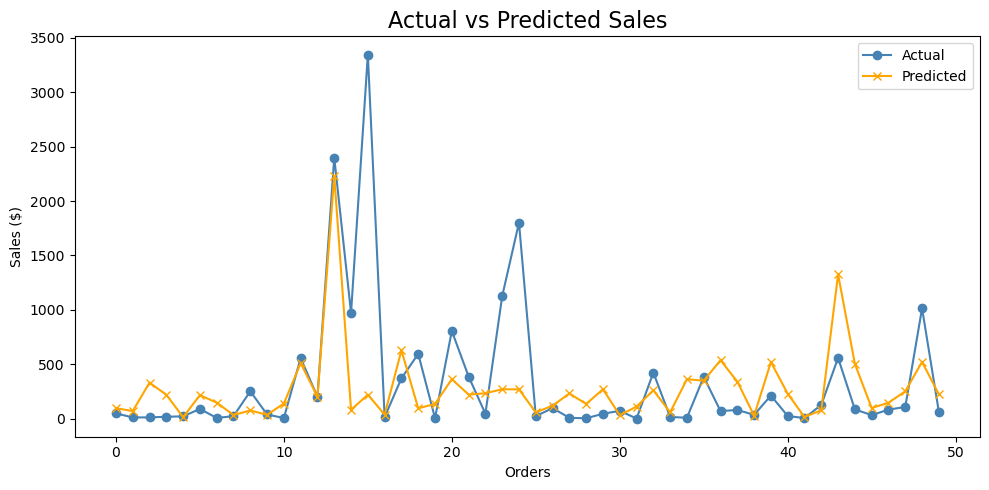

In [114]:
plt.figure(figsize=(10, 5))
plt.plot(Y_test.values[:50], label='Actual', marker='o', color='steelblue')
plt.plot(Y_pred[:50], label='Predicted', marker='x', color='orange')
plt.title('Actual vs Predicted Sales', fontsize=16)
plt.xlabel('Orders')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()